[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Zaba_et_al/isotopic_ratios.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Zaba_et_al/isotopic_ratios.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Zaba_et_al/isotopic_ratios.ipynb)

# Isotopic ratios
TODO PySDM/physics/isotope_ratio_evolution/merlivat_and_jouzel_1979.py -> d_Rv_over_Rv

- three isotopes
- ice and water
- TEST: tau vs Bo

In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [2]:
import numpy as np
from matplotlib import pyplot
from collections import namedtuple
from mpl_toolkits.mplot3d import proj3d
from scipy.interpolate import RegularGridInterpolator
from open_atmos_jupyter_utils import show_plot

from PySDM import Formulae
from PySDM.dynamics.isotopic_fractionation import HEAVY_ISOTOPES
from PySDM.physics.constants import si, PER_MILLE, in_unit, PER_CENT
from examples.PySDM_examples.Zaba_et_al.simulation import Simulation

In [3]:
IsotopeContext = namedtuple("IsotopeContext", ["iso", "T"])
Parameters = namedtuple(
    "params", [
        "D_ratio",
        "f_ratio",
        "alpha_w",
        "alpha_i",
        "Fk_plus_Fd",
        "b",
        "vsmow",
    ]
)

Commons = namedtuple("Commons", ["f", "c", "iso", "T", "params"])

class CommonsFactory:
    """Compute and assemble common isotope quantities."""
    def __init__(self, formulae):
        self._f = formulae
        self._const = formulae.constants

    def build(self, ctx: IsotopeContext):
        """build factory"""
        return Commons(
            f=self._f,
            c=self._const,
            iso=ctx.iso,
            T=ctx.T,
            params=self._build_params(ctx),
        )

    def _build_params(self, ctx):
        vsmow = getattr(self._const, f"VSMOW_R_{ctx.iso}")
        diff_fun = getattr(
            self._f.isotope_diffusivity_ratios,
            f"ratio_{ctx.iso}_heavy_to_light",
        )
        D_ratio = diff_fun(ctx.T) 
        ventilation_ratio = (
            self._f.isotope_ventilation_ratio.ratio_heavy_to_light(
                ventilation_coefficient=np.nan,
                diffusivity_ratio_heavy_to_light=D_ratio,
            )
        )
        alpha_l = getattr(
            self._f.isotope_equilibrium_fractionation_factors,
            f'alpha_l_{ctx.iso}',
        )
        alpha_i = getattr(
            self._f.isotope_equilibrium_fractionation_factors,
            f'alpha_i_{ctx.iso}',
        )
        pvs = self._f.saturation_vapour_pressure.pvs_water(ctx.T)
        Fk = self._f.drop_growth.Fk(
            T=ctx.T,
            K=self._const.K0,
            lv=self._f.latent_heat_vapourisation.lv(ctx.T),
        )
        Fd = self._f.drop_growth.Fd(
            pvs=pvs,
            T=ctx.T,
            D=self._const.D0,
        )
        rho_s = pvs / self._const.Rv / ctx.T
        return Parameters(
            D_ratio=D_ratio,
            f_ratio=ventilation_ratio,
            alpha_w=alpha_l(ctx.T),
            alpha_i=alpha_i(ctx.T),
            Fk_plus_Fd=Fk + Fd,
            b=rho_s * Fk / self._const.rho_w * self._const.D0,
            vsmow=vsmow,
        )
    
C2K = Formulae().trivia.C2K

In [4]:
def no_fractionation_saturation(x, iso_ratio_v, cmn, phase):
    iso_ratio_r = x * cmn.params.vsmow
    return cmn.f.isotope_ratio_evolution.saturation_for_zero_dR_condition(
        iso_ratio_x=iso_ratio_r if phase=='liquid' else iso_ratio_v,
        diff_rat_light_to_heavy=(
            cmn.params.f_ratio / cmn.params.D_ratio
        ),
        b=cmn.params.b,
        alpha_w=cmn.params.alpha_w,
        iso_ratio_r=iso_ratio_r,
        iso_ratio_v=iso_ratio_v,
    )

def calculate_delta_change(
    *,
    relative_humidity,
    molecular_R_liq,
    multiplicity,
    commons,
    volume,
    radius,
):  # pylint: disable=too-many-arguments
    """perform multiple calculations for different grid nodes
    result: matrix of relative mass change of the heavy isotope
    in liquid and vapour phase"""
    dR_dt_vap = np.zeros((len(relative_humidity), len(molecular_R_liq)))
    dR_dt_liq = np.zeros_like(dR_dt_vap)
    Bolin_number = np.zeros_like(dR_dt_vap)
    
    attributes = ATTRIBUTES.copy()
    attributes["multiplicity"] = multiplicity
    attributes['signed water mass'] = commons.c.rho_w * 4 / 3 * np.pi * radius**3
    for i, rh in enumerate(relative_humidity):
        c = (
            4 * np.pi * commons.c.rho_w
            / commons.params.Fk_plus_Fd
        )
        for j, m_R_liq in enumerate(molecular_R_liq):
            particulator, init_conc_vap = Simulation.make_particulator(
                ff=commons.f,
                molecular_isotopic_ratio=m_R_liq,
                initial_R_vap=ISO_RATIO_V,
                attributes=attributes,
                n_sd=1,
                relative_humidity=rh,
                dv=volume,
                T=commons.T,
                dt=666 * si.s,
                isotope=commons.iso,
            )
            dR_dt_vap[i,j], dR_dt_liq[i,j], Bolin_number[i,j] = Simulation.do_one_step(
                ff=commons.f,
                particulator=particulator,
                dm_dt_per_droplet=c * radius * (rh - 1),
                init_m_R_liq=m_R_liq,
                initial_conc_vap=init_conc_vap,
                isotope=commons.iso,
            )
    return dR_dt_vap/commons.params.vsmow, dR_dt_liq/commons.params.vsmow, Bolin_number

In [5]:
class Paper:
    """Configuration reproducing the paper setup."""
    formulae = Formulae(
        isotope_equilibrium_fractionation_factors="MerlivatAndNief1967+Majoube1971",
        isotope_kinetic_fractionation_factors="JouzelAndMerlivat1984",
        isotope_relaxation_timescale="ZabaEtAl",
        isotope_diffusivity_ratios="Stewart1975",
        isotope_ratio_evolution="GedzelmanAndArnold1994",
        isotope_ventilation_ratio="Neglect",  # droplet-size dependent, ignored here
        drop_growth="Mason1971",
    )
    isotope = "2H"
    delta_v = -200 * PER_MILLE
    temperature = C2K(10.0) * si.K
    xlim = (0.8, 1.05)
    rh_lim = (0.0, 1.05)
    rh_unit = PER_CENT

ATTRIBUTES = {
    "dry volume": np.nan,
    "kappa times dry volume": np.nan,
    **{f"moles_{isotope}": 0.0 * si.mole for isotope in HEAVY_ISOTOPES},
    "multiplicity": 1 * np.ones(1),
}

cmn = CommonsFactory(Paper.formulae).build(
    IsotopeContext(iso=Paper.isotope, T=Paper.temperature)
)
ISO_RATIO_V = cmn.f.trivia.isotopic_delta_2_ratio(Paper.delta_v, cmn.params.vsmow)

In [6]:
grid = (32, 32)
r_pristine = 0.5 * si.mm
nd_pristine, nd_polluted = 10, 30
r_polluted=nd_pristine * r_pristine / nd_polluted

d_delta_dt = {}
Bo = {}
for aerosol, nd, r in zip(("pristine", "polluted"), (nd_pristine, nd_polluted), (r_pristine, r_polluted)):
    d_delta_dt[aerosol] = {}
    d_delta_dt_vap, d_delta_dt_liq, Bolin_number = calculate_delta_change(
        relative_humidity=np.linspace(*Paper.rh_lim, grid[1]),
        molecular_R_liq=np.linspace(*Paper.xlim, grid[0]) * cmn.params.vsmow,
        multiplicity=nd * np.ones(1),
        commons=cmn,
        volume=np.ones(1) * si.dm**3,
        radius=r,
    )
    d_delta_dt[aerosol]["liquid"] = d_delta_dt_liq
    d_delta_dt[aerosol]["vapor"] = d_delta_dt_vap
    Bo[aerosol] = Bolin_number

/Users/agnieszkazaba/PycharmProjects/PySDM/PySDM/backends/numba.py:57: UserWarning: Disabling Numba threading due to ARM64 CPU (atomics do not work yet)
  warnings.warn(


In [7]:
phases = ("liquid", "vapor")
eps=1e-2

def xy_masked(x, y):
    mask = (
        (x >= Paper.xlim[0]) & (x <= Paper.xlim[1]) &
        (y >= Paper.rh_lim[0]) & (y <= Paper.rh_lim[1])
    )
    return x[mask], y[mask], mask

def z_eps_mask(z, eps):
    return {
        'z < -': np.where(z < -eps, z, np.nan),
        '|z| <': np.where(np.abs(z) < eps, z, np.nan),
        'z >': np.where(z > eps, z, np.nan),
    }
eps_colors = {
                'z < -': 'darkblue',
                '|z| <': 'pink',
                'z >': 'gold'
            }    

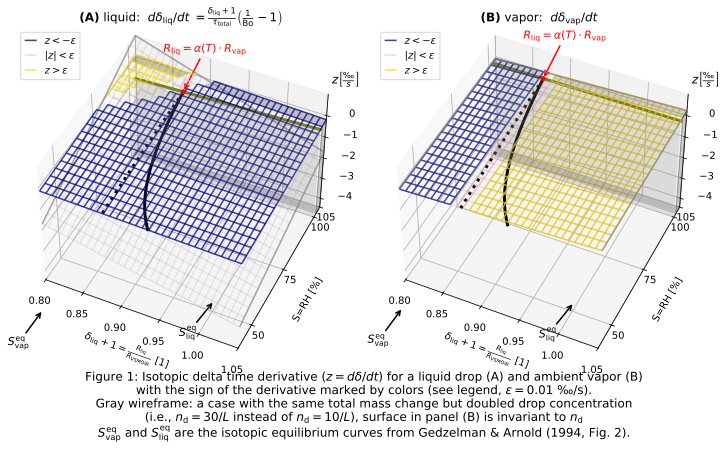

In [8]:
fig, axs = pyplot.subplots(
    1, 2,
    figsize=(10, 8),
    subplot_kw={'projection': '3d'},
    constrained_layout=True,
)

X = np.linspace(*Paper.xlim, grid[0])
Y = in_unit(np.linspace(*Paper.rh_lim, grid[1]), Paper.rh_unit)
XX, YY = np.meshgrid(X, Y)
X_eq = ISO_RATIO_V * cmn.params.alpha_w /cmn.params.vsmow
Y_eq = in_unit(1, Paper.rh_unit)

in_cloud = Y >= Y_eq
cloud_XX, cloud_YY = np.meshgrid(X, Y[in_cloud])
zmin = np.nanmin([vals for vals in d_delta_dt["polluted"].values()]) / PER_MILLE
zmax = np.nanmax([vals for vals in d_delta_dt["polluted"].values()]) / PER_MILLE

kw_ann = dict(
    xy=(0,0),
    fontsize=11,
    textcoords='offset points',
)
def update(x, y, z, ann):
    def update(event):
        x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
        ann.xy = (x2, y2)
    return update


for ax, phase in zip(axs, phases):
    Z = in_unit(d_delta_dt["pristine"][phase], PER_MILLE)
    Zp = in_unit(d_delta_dt["polluted"][phase], PER_MILLE)
    interp = RegularGridInterpolator((X, Y), Z)

    ax.plot_wireframe(XX, YY, Zp, color="grey", alpha=0.15, zorder=2.05, axlim_clip=True,)
    for label, z in z_eps_mask(Z, eps).items():
        ax.plot_wireframe(XX, YY, z,
                          label=f"${label}\epsilon$",
                          alpha=0.75,
                          color=eps_colors[label],
                          zorder=2.05,
                          axlim_clip=True,
                          )
        ax.plot_surface(cloud_XX, cloud_YY, z[in_cloud, :], color="grey", alpha=0.3)

    tmp = Zp.copy()
    tmp[1:-1, 1:-1] = np.nan
    ax.plot_wireframe(XX, YY, tmp,
                      color="grey",
                      alpha=0.65,
                      zorder=2.05,
                      axlim_clip=True,
                      )
    
    ax.plot_surface(cloud_XX, cloud_YY,
                    np.full_like(cloud_XX, zmin),
                    color="grey", alpha=0.3, edgecolor="none")
    xy = X, Y_eq
    z_line = interp(np.c_[X, np.full_like(X, Y_eq)])
    ax.fill_between(*xy, zmin, *xy, z_line, color="grey", alpha=0.2, edgecolor="none")
    ax.plot(*xy, z_line, c='olive', lw=3, zorder=3)

    xy_edge = np.full_like(Y[in_cloud], X[-1]), Y[in_cloud]
    z_line2 = interp(np.column_stack(xy_edge))
    ax.fill_between(*xy_edge, zmin,
                    *xy_edge, z_line2,
                    color="grey", alpha=0.35, edgecolor="k")

    z_point = interp((X_eq, Y_eq))
    ax.scatter(X_eq, Y_eq, z_point, color='red', s=15, zorder=20)
    ann = ax.annotate(
        r'$R_\text{liq} = \alpha(T)\cdot R_{\text{vap}}$',
        xytext=(-20, 40),
        arrowprops={"arrowstyle": '->', "color": 'red', "lw": 1.5},
        color='red',
        **kw_ann,
    )
    fig.canvas.mpl_connect('draw_event', update(X_eq, Y_eq, z_point, ann))
    
    for p, ls in zip(phases, ('-', ':')):
        x, y, mask = xy_masked(
            x=(x:= np.linspace(X_eq, 1.05, 2000)),
            y=no_fractionation_saturation(x, ISO_RATIO_V, cmn, p)
        )
        y = in_unit(y, Paper.rh_unit)
        z_line = interp(np.c_[x, y])
        ax.plot(x, y, z_line, c='k', lw=3, ls=ls, zorder=3, axlim_clip=True,)

        ann = ax.annotate(
            rf"$S_\text{{{p[:3]}}}^\text{{eq}}$",
            xytext=(-35, -35),
            arrowprops={"arrowstyle": '->', "color": 'k', "lw": 1.5},
            **kw_ann,
        )
        fig.canvas.mpl_connect(
            'draw_event',
            update(x[-1], y[-1], z_line[-1], ann)
        )
    ax.text2D(
        1, 0.83,
        rf"$z \left[\frac{{‰}}{{s}}\right]$",
        transform=ax.transAxes,
        fontsize=12,
        ha='center',
    )
    ann = ax.annotate(
        'phase equil.\n  RH=100%',
        xytext=(-130, 0),
        arrowprops={"arrowstyle": '->', "color": 'olive', "lw": 1.5},
        color='olive',
        **kw_ann,
    )
    fig.canvas.mpl_connect('draw_event', update(X[0], 100, Z[0, np.argmin(in_cloud)], ann))
    elaborate = "" if phase[0] == 'v' else r"$=\frac{\delta_\text{liq}+1}{\tau_\text{total}}\left(\frac{1}{\text{Bo}}-1\right)$"
    ax.set_title(rf"$\bf{{({ {'l':'A', 'v':'B'}[phase[0]] })}}$ {phase}:  ${{d\delta_\text{{{phase[:3]}}}}}/{{dt}}$ " + elaborate, fontsize=12)


for i, ax in enumerate(axs.flat):
    ax.set(
        xlim=Paper.xlim,
        ylim=(40, 105),
        yticks=(50, 75, 100, 105),
        ylabel="S=RH [%]",
        xlabel=r"$\delta_\text{liq} + 1 = \frac{R_\text{liq}}{R_\text{VSMOW}}$ [1]",
        zlim=(zmin, zmax),
    )

    ax.view_init(elev=45, azim=-65)
    ax.tick_params(axis='y', pad=-2)
    ax.tick_params(axis='z', pad=8)
    ax.legend(loc="upper left", handlelength=1.2)

text = f"""Figure 1: Isotopic delta time derivative ($z=d\\delta/dt$) for a liquid drop $\\bf{{\\text{{(A)}}}}$ and ambient vapor $\\bf{{\\text{{(B)}}}}$
with the sign of the derivative marked by colors (see legend, $\\epsilon={eps}\\,\\,\\text{{‰/s}}$).
Gray wireframe: a case with the same total mass change but doubled drop concentration
(i.e., $n_\\text{{d}} = {nd_polluted}/L$ instead of $n_\\text{{d}} = {nd_pristine}/L$), surface in panel (B) is invariant to $n_\\text{{d}}$
$S^\\text{{eq}}_\\text{{vap}}$ and $S^\\text{{eq}}_\\text{{liq}}$ are the isotopic equilibrium curves from Gedzelman & Arnold (1994, Fig. 2)."""

fig.text(0.5, 0.075, text, ha="center", fontsize=12)
pyplot.savefig('ams-plot.png')
show_plot("comparison")